In [1]:
# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning
    
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import boto3
from sklearn.linear_model import LogisticRegression

(CVXPY) Feb 20 11:19:41 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Feb 20 11:19:41 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

#### Constants

In [3]:
str_uri = 's3://20250121-gen-13-model-monitoring/07_compare_debtor/df.gzip'

str_target = 'Early_Pay_Delinquency_60_720_Flag'

list_cols = [
    'g232s__tu',
    'ENG-wtd_avg',
#     'ENG-bk',
            ]

# dict monotone constraints
dict_monotone_constraints = {'g232s__tu':1,
                            'ENG-wtd_avg':-1}

# output
str_dirname_output = './output'

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

# factor 24 to 72
flt_factor_24_to_72 = 2.36

# pd threshold
flt_threshold_pd = 0.6

#### Makr output dir

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

# ENG-wtd_avg

In [5]:
# pull data
df = pd.read_parquet(str_uri)

# g232s impute to 383 (max)
df['g232s__tu'] = df['g232s__tu'].fillna(383)

# subset BKs
df = df[df['intopenbktype__app'].isna()]

# group by
df = df.groupby('accountid').agg({
    'pd_gen13': 'mean', 
    'lgd_gen13': 'mean',
    'pd_gen12': 'mean', 
    'lgd_gen12': 'mean',    
    'g232s__tu': 'sum',
    'ENG-wtd_avg': 'mean',
}).reset_index()

# calculate ecnl_gen12
df['ecnl_gen12'] = df['pd_gen12'] * df['lgd_gen12'] * flt_factor_24_to_72

# get tier
df['tier_gen12'] = df['ecnl_gen12'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)

# calculate ecnl_gen13
df['ecnl_gen13'] = df['pd_gen13'] * df['lgd_gen13'] * flt_factor_24_to_72

# get tier
df['tier_gen13'] = df['ecnl_gen13'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)

# get bitapproved g12
df['bitapproved_gen12'] = np.where(df['tier_gen12'] == 'Decline', 0, 1)

# get bitapproved g13
df['bitapproved_gen13'] = np.where(df['tier_gen13'] == 'Decline', 0, 1)

# int n total
int_n_total = df.shape[0]

df

,accountid,pd_gen13,lgd_gen13,pd_gen12,lgd_gen12,g232s__tu,ENG-wtd_avg,ecnl_gen12,tier_gen12,ecnl_gen13,tier_gen13,bitapproved_gen12,bitapproved_gen13
0,8377904,0.398371,0.390043,0.109799,0.661674,6.0,0.884848,0.171457,B,0.366701,Decline,1,0
1,8406563,0.701699,0.390043,0.195628,0.711966,23.0,0.000000,0.328703,D,0.645914,Decline,1,0
2,8410612,0.501303,0.390043,0.185327,0.666911,14.0,0.288889,0.291688,C,0.461449,Decline,1,0
3,8425182,0.303218,0.010000,0.246189,0.669907,17.0,0.000000,0.389220,Decline,0.007156,A1,0,1
4,8426075,0.473945,0.350185,0.119344,0.632764,22.0,1.000000,0.178219,B,0.391685,Decline,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20011,8656633,0.784926,0.390043,0.267640,0.618495,383.0,0.000000,0.390660,Decline,0.722525,Decline,0,0
20012,8656635,0.411855,0.277756,0.172957,0.665373,48.0,0.560606,0.271590,C,0.269973,C,1,1
20013,8656636,0.371297,0.390043,0.206047,0.640636,18.0,1.000000,0.311522,C,0.341779,D,1,1
20014,8656638,0.719853,0.350185,0.472883,0.728579,22.0,0.466403,0.813096,Decline,0.594912,Decline,0,0


In [6]:
# create bins
bins_ = np.linspace(0, 1.00, 101)

# create results
results = []

# Loop
for i in range(len(bins_) - 1):
    lower, upper = bins_[0], bins_[i + 1]

    # filter df to values within bins
    subset = df[(df['ENG-wtd_avg'] >= lower) & (df['ENG-wtd_avg'] <= upper)]
    
    # prop approved g12 ================================================================================
    prop_approved_g12 = subset['bitapproved_gen12'].mean()
    
    # get total g12
    shape_total_g12 = subset.shape[0]
    
    # get total approved g12
    subset_approved_g12 = subset[subset['bitapproved_gen12'] == 1]
    shape_total_approved_g12 = subset_approved_g12.shape[0]
    
    # prop approved g13 ================================================================================
    prop_approved_g13 = subset['bitapproved_gen13'].mean()
    
    # get total g12
    shape_total_g13 = subset.shape[0]
    
    # get total approved g12
    subset_approved_g13 = subset[subset['bitapproved_gen13'] == 1]
    shape_total_approved_g13 = subset_approved_g13.shape[0]    
    
    
    # append
    results.append({
        'max ENG-wtd_avg': f'{upper:.2f}',
        'count_approved_gen12': shape_total_approved_g12,
        'count_total_gen12': shape_total_g12,
        'prop_approved_gen12': prop_approved_g12,
        'count_approved_gen13': shape_total_approved_g13,
        'count_total_gen13': shape_total_g13,
        'prop_approved_gen13': prop_approved_g13,        
    })

# create df
df_result = pd.DataFrame(results)

# save df
df_result.to_csv(f'{str_dirname_output}/df_result_wtd_avg.csv', index=False)

# show
df_result

,max ENG-wtd_avg,count_approved_gen12,count_total_gen12,prop_approved_gen12,count_approved_gen13,count_total_gen13,prop_approved_gen13
0,0.01,2255,5873,0.383960,1854,5873,0.315682
1,0.02,2343,6139,0.381658,1949,6139,0.317478
2,0.03,2406,6329,0.380155,2010,6329,0.317586
3,0.04,2475,6528,0.379136,2078,6528,0.318321
4,0.05,2522,6657,0.378849,2118,6657,0.318161
...,...,...,...,...,...,...,...
95,0.96,6341,15171,0.417968,5876,15171,0.387318
96,0.97,6420,15277,0.420240,5955,15277,0.389802
97,0.98,6487,15366,0.422166,6023,15366,0.391969
98,0.99,6539,15440,0.423510,6079,15440,0.393718


#### Plot it

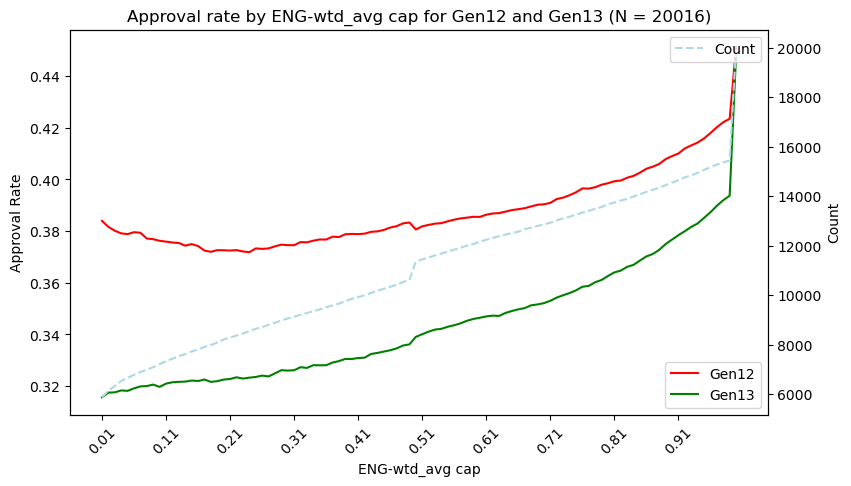

In [7]:
x = df_result['max ENG-wtd_avg']
y = df_result['prop_approved_gen12']
z = df_result['prop_approved_gen13']
a = df_result['count_total_gen12']
b = df_result['count_total_gen13']
str_title = f'Approval rate by ENG-wtd_avg cap for Gen12 and Gen13 (N = {int_n_total})'
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('ENG-wtd_avg cap')
ax.set_ylabel('Approval Rate')
ax.plot(x, y, color='red', label='Gen12')
ax.plot(x, z, color='green', label='Gen13')
ax.set_xticks(x[::10])  
ax.set_xticklabels(x[::10], rotation=45)
ax.legend(loc='lower right')
# second y
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(x, a, linestyle='--', color='lightblue', label='Count')
# ax2.plot(x, b, linestyle='--', color='lightyellow', label='Count Gen 13')
ax2.legend(loc='upper right')
# show
plt.show()


# g232s__tu

In [8]:
df.g232s__tu.max()

766.0

In [9]:
df.shape[0]

20016

In [10]:
# pull data
df = pd.read_parquet(str_uri)

# g232s impute to 383 (max)
df['g232s__tu'] = df['g232s__tu'].fillna(383)

# # subset BKs
# df = df[df['intopenbktype__app'].isna()]

# group by
df = df.groupby('accountid').agg({
    'pd_gen13': 'mean', 
    'lgd_gen13': 'mean',
    'pd_gen12': 'mean', 
    'lgd_gen12': 'mean',    
    'g232s__tu': 'sum',
    'ENG-wtd_avg': 'mean',
}).reset_index()

# calculate ecnl_gen12
df['ecnl_gen12'] = df['pd_gen12'] * df['lgd_gen12'] * flt_factor_24_to_72

# get tier
df['tier_gen12'] = df['ecnl_gen12'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)

# calculate ecnl_gen13
df['ecnl_gen13'] = df['pd_gen13'] * df['lgd_gen13'] * flt_factor_24_to_72

# get tier
df['tier_gen13'] = df['ecnl_gen13'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)

# get bitapproved g12
df['bitapproved_gen12'] = np.where(df['tier_gen12'] == 'Decline', 0, 1)

# get bitapproved g13
df['bitapproved_gen13'] = np.where(df['tier_gen13'] == 'Decline', 0, 1)

# int n total
int_n_total = df.shape[0]

df

,accountid,pd_gen13,lgd_gen13,pd_gen12,lgd_gen12,g232s__tu,ENG-wtd_avg,ecnl_gen12,tier_gen12,ecnl_gen13,tier_gen13,bitapproved_gen12,bitapproved_gen13
0,8268533,0.263986,0.323245,0.080307,0.635658,23.0,1.000000,0.120472,A,0.201384,B,1,1
1,8337231,0.487426,0.259641,0.182324,0.714280,15.0,0.166667,0.307344,C,0.298672,C,1,1
2,8377904,0.398371,0.390043,0.109799,0.661674,6.0,0.884848,0.171457,B,0.366701,Decline,1,0
3,8406563,0.701699,0.390043,0.195628,0.711966,23.0,0.000000,0.328703,D,0.645914,Decline,1,0
4,8408086,0.285585,0.172898,0.097434,0.643186,22.0,1.000000,0.147897,B,0.116530,A,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21726,8656635,0.411855,0.277756,0.172957,0.665373,48.0,0.560606,0.271590,C,0.269973,C,1,1
21727,8656636,0.371297,0.390043,0.206047,0.640636,18.0,1.000000,0.311522,C,0.341779,D,1,1
21728,8656638,0.719853,0.350185,0.472883,0.728579,22.0,0.466403,0.813096,Decline,0.594912,Decline,0,0
21729,8656640,0.264077,0.350185,0.156200,0.591635,5.0,1.000000,0.218096,B,0.218242,B,1,1


In [11]:
# create bins
bins_ = np.linspace(0, 766, 767)

# create results
results = []

# Loop
for i in range(len(bins_) - 1):
    lower, upper = bins_[0], bins_[i + 1]

    # filter df to values within bins
    subset = df[(df['g232s__tu'] >= lower) & (df['g232s__tu'] <= upper)]
    
    # prop approved g12 ================================================================================
    prop_approved_g12 = subset['bitapproved_gen12'].mean()
    
    # get total g12
    shape_total_g12 = subset.shape[0]
    
    # get total approved g12
    subset_approved_g12 = subset[subset['bitapproved_gen12'] == 1]
    shape_total_approved_g12 = subset_approved_g12.shape[0]
    
    # prop approved g13 ================================================================================
    prop_approved_g13 = subset['bitapproved_gen13'].mean()
    
    # get total g12
    shape_total_g13 = subset.shape[0]
    
    # get total approved g12
    subset_approved_g13 = subset[subset['bitapproved_gen13'] == 1]
    shape_total_approved_g13 = subset_approved_g13.shape[0]    
    
    
    # append
    results.append({
        'max g232s__tu': f'{upper:.2f}',
        'count_approved_gen12': shape_total_approved_g12,
        'count_total_gen12': shape_total_g12,
        'prop_approved_gen12': prop_approved_g12,
        'count_approved_gen13': shape_total_approved_g13,
        'count_total_gen13': shape_total_g13,
        'prop_approved_gen13': prop_approved_g13,        
    })

# create df
df_result = pd.DataFrame(results)

# save df
df_result.to_csv(f'{str_dirname_output}/df_result_g232s.csv', index=False)

# show
df_result

,max g232s__tu,count_approved_gen12,count_total_gen12,prop_approved_gen12,count_approved_gen13,count_total_gen13,prop_approved_gen13
0,1.00,283,396,0.714646,255,396,0.643939
1,2.00,735,1078,0.681818,747,1078,0.692950
2,3.00,1307,1970,0.663452,1340,1970,0.680203
3,4.00,1911,2981,0.641060,1976,2981,0.662865
4,5.00,2545,4072,0.625000,2643,4072,0.649067
...,...,...,...,...,...,...,...
761,762.00,10318,21725,0.474937,10383,21725,0.477929
762,763.00,10318,21725,0.474937,10383,21725,0.477929
763,764.00,10318,21725,0.474937,10383,21725,0.477929
764,765.00,10318,21725,0.474937,10383,21725,0.477929


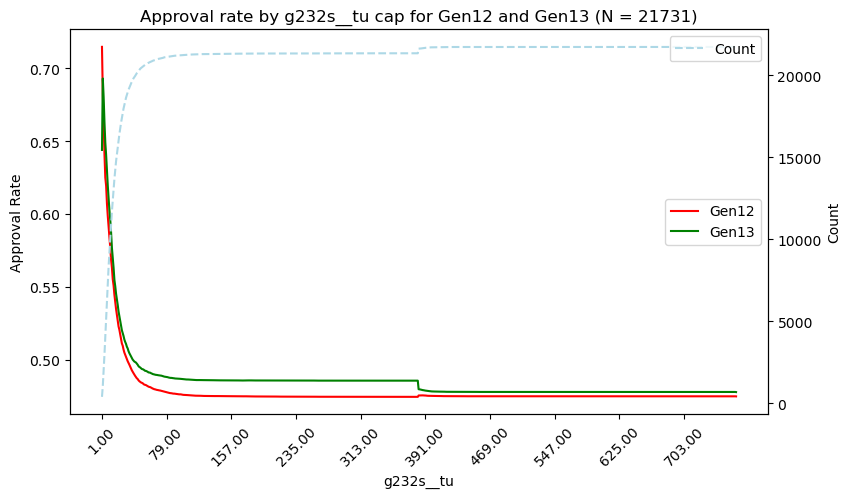

In [12]:
x = df_result['max g232s__tu']
y = df_result['prop_approved_gen12']
z = df_result['prop_approved_gen13']
a = df_result['count_total_gen12']
b = df_result['count_total_gen13']
str_title = f'Approval rate by g232s__tu cap for Gen12 and Gen13 (N = {int_n_total})'
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('g232s__tu')
ax.set_ylabel('Approval Rate')
ax.plot(x, y, color='red', label='Gen12')
ax.plot(x, z, color='green', label='Gen13')
ax.set_xticks(x[::78])  
ax.set_xticklabels(x[::78], rotation=45)
ax.legend(loc='center right')
# second y
ax2 = ax.twinx()
ax2.set_ylabel('Count')
ax2.plot(x, a, linestyle='--', color='lightblue', label='Count')
# ax2.plot(x, b, linestyle='--', color='lightyellow', label='Count Gen 13')
ax2.legend(loc='upper right')
# show
plt.show()